In [ ]:
!pip install -q xgboost imbalanced-learn shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


**Import libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [ ]:
# Change file name if Colab shows a slightly different name
df = pd.read_csv("Healthcare Ransomware Dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5000, 16)


,id,attack_date,org_type,org_size,facilities_affected,cyber_threats_tracked,monitoring_freq,backup_compromised,ransomware_infection_rate_(%),data_encrypted,data_stolen,recovery_time_(days),entry_method,paid_ransom,data_restored,ransomware_incidents
0,RAN202400001,28/06/2024 00:00,Hospital,Large,23,Jan-50,Daily,True,63.30,True,False,64,Exploited Vulnerability,False,36.28,2
1,RAN202400002,18/12/2024 03:00,Pharma,Medium,4,50-350,Daily,False,59.05,True,True,28,Exploited Vulnerability,True,57.66,6
2,RAN202400003,12/10/2024 09:00,Research Lab,Small,18,350+,Daily,True,90.00,True,False,49,Phishing Email,True,61.85,5
3,RAN202400004,28/07/2024 19:00,Clinic,Small,5,Jan-50,Weekly,True,61.32,False,False,56,Compromised Credentials,False,52.44,5
4,RAN202400005,27/06/2024 18:00,Hospital,Large,16,350+,Daily,False,53.65,True,True,13,Exploited Vulnerability,True,75.61,2


**Clean column names**

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("%", "percent", regex=False)
)

df.columns

Index(['id', 'attack_date', 'org_type', 'org_size', 'facilities_affected',
       'cyber_threats_tracked', 'monitoring_freq', 'backup_compromised',
       'ransomware_infection_rate_percent', 'data_encrypted', 'data_stolen',
       'recovery_time_days', 'entry_method', 'paid_ransom', 'data_restored',
       'ransomware_incidents'],
      dtype='object')

**Convert date column and fix cyber threat category**

In [ ]:
df["attack_date"] = pd.to_datetime(df["attack_date"], errors="coerce", dayfirst=True)

# Fix possible "Jan-50" formatting issue caused by Excel
df["cyber_threats_tracked"] = df["cyber_threats_tracked"].replace({
    "Jan-50": "1-50"
})

df.head()

,id,attack_date,org_type,org_size,facilities_affected,cyber_threats_tracked,monitoring_freq,backup_compromised,ransomware_infection_rate_percent,data_encrypted,data_stolen,recovery_time_days,entry_method,paid_ransom,data_restored,ransomware_incidents
0,RAN202400001,2024-06-28 00:00:00,Hospital,Large,23,1-50,Daily,True,63.30,True,False,64,Exploited Vulnerability,False,36.28,2
1,RAN202400002,2024-12-18 03:00:00,Pharma,Medium,4,50-350,Daily,False,59.05,True,True,28,Exploited Vulnerability,True,57.66,6
2,RAN202400003,2024-10-12 09:00:00,Research Lab,Small,18,350+,Daily,True,90.00,True,False,49,Phishing Email,True,61.85,5
3,RAN202400004,2024-07-28 19:00:00,Clinic,Small,5,1-50,Weekly,True,61.32,False,False,56,Compromised Credentials,False,52.44,5
4,RAN202400005,2024-06-27 18:00:00,Hospital,Large,16,350+,Daily,False,53.65,True,True,13,Exploited Vulnerability,True,75.61,2


**Missing values check**

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
id,0
attack_date,0
org_type,0
org_size,0
facilities_affected,0
cyber_threats_tracked,0
monitoring_freq,0
backup_compromised,0
ransomware_infection_rate_percent,0
data_encrypted,0


**Duplicate values check**

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Target class distribution**

In [ ]:
target_cols = ["paid_ransom", "data_encrypted"]

for col in target_cols:
    print(f"\nClass distribution for {col}:")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True) * 100)


Class distribution for paid_ransom:
paid_ransom
False    2532
True     2468
Name: count, dtype: int64
paid_ransom
False    50.64
True     49.36
Name: proportion, dtype: float64

Class distribution for data_encrypted:
data_encrypted
True     4241
False     759
Name: count, dtype: int64
data_encrypted
True     84.82
False    15.18
Name: proportion, dtype: float64


**Visualize target imbalance**

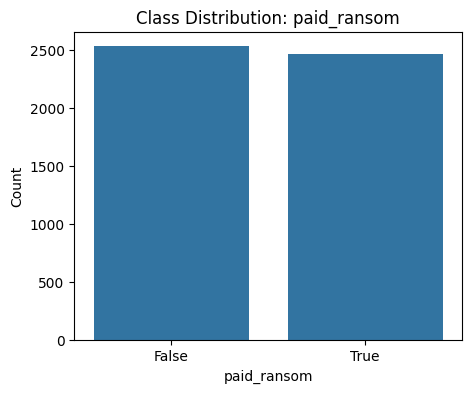

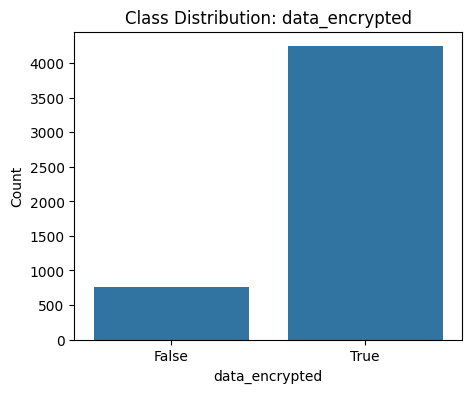

In [ ]:
for col in target_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Class Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

**Exploratory data analysis — categorical features**

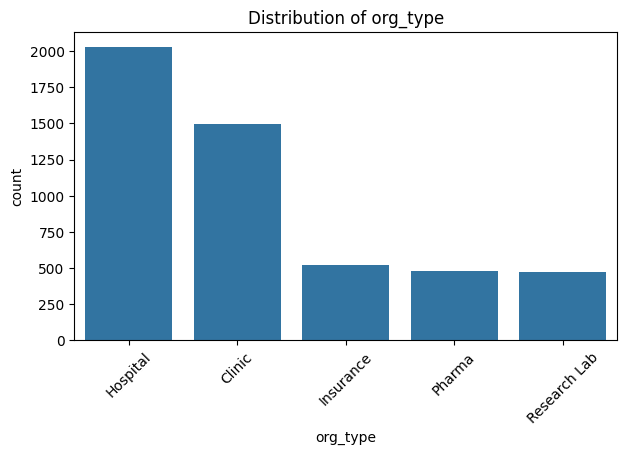

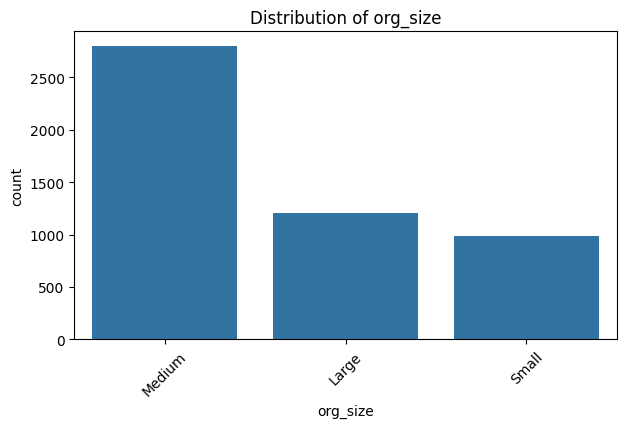

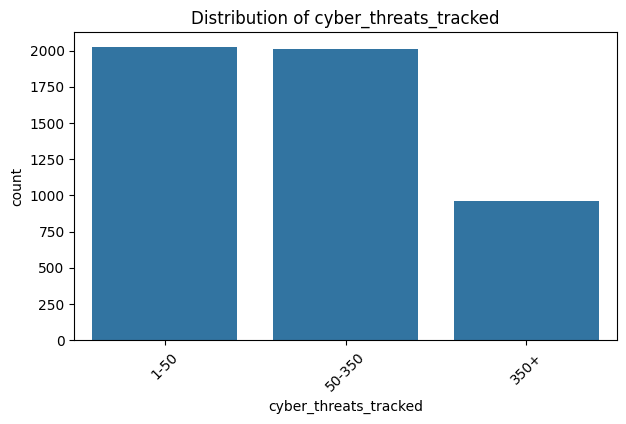

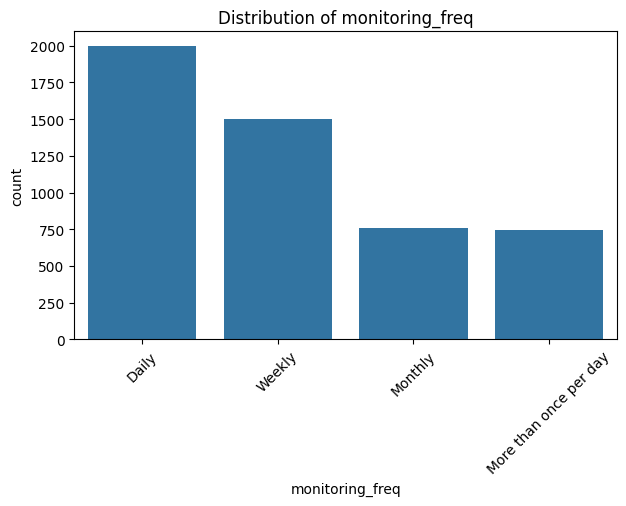

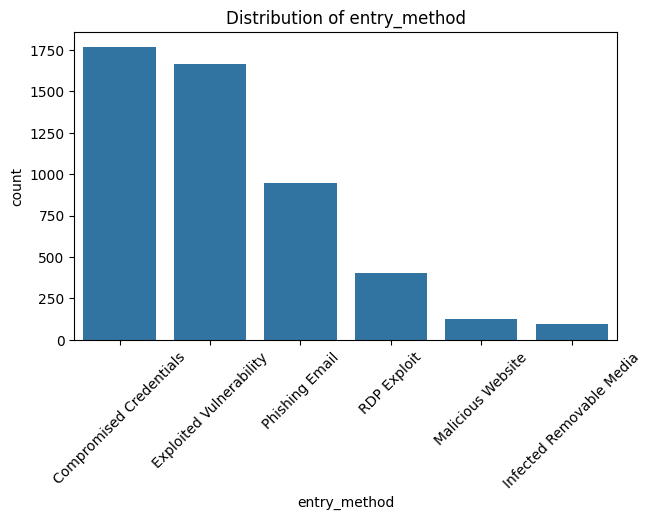

In [ ]:
categorical_cols = [
    "org_type",
    "org_size",
    "cyber_threats_tracked",
    "monitoring_freq",
    "entry_method"
]

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

**Exploratory data analysis — numerical features**

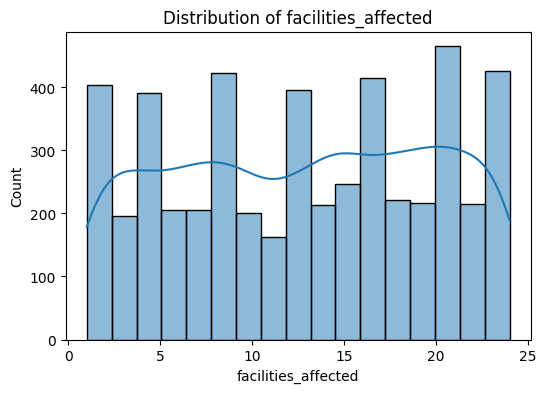

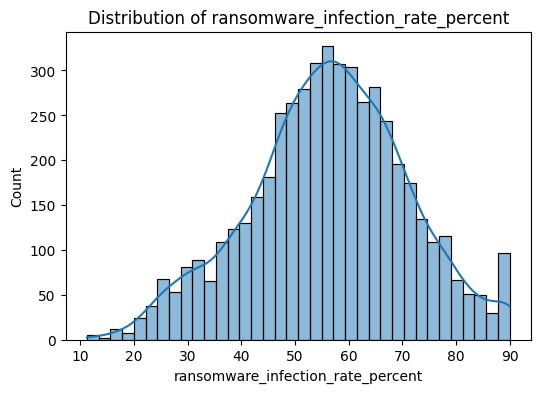

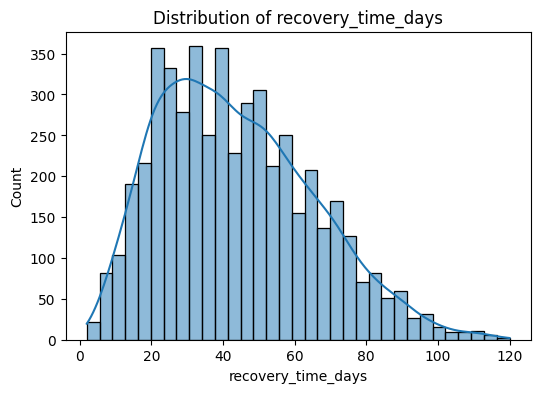

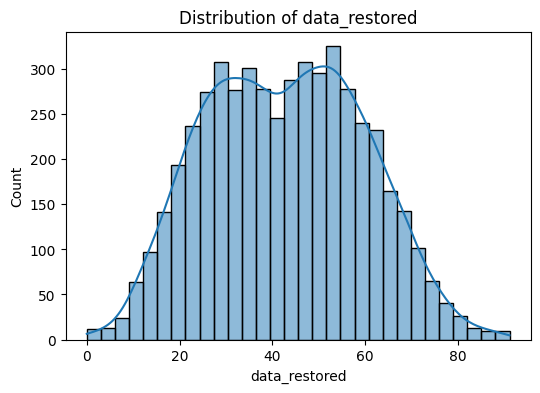

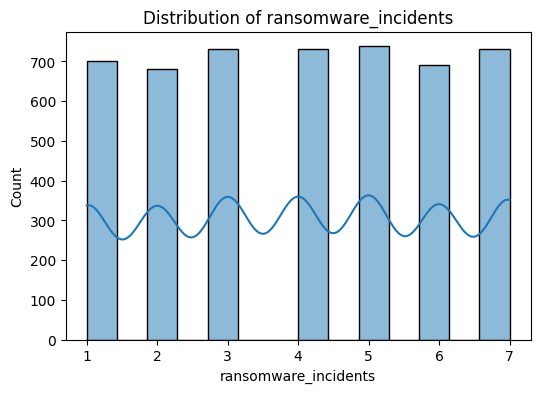

In [ ]:
numeric_cols = [
    "facilities_affected",
    "ransomware_infection_rate_percent",
    "recovery_time_days",
    "data_restored",
    "ransomware_incidents"
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

**Correlation analysis**

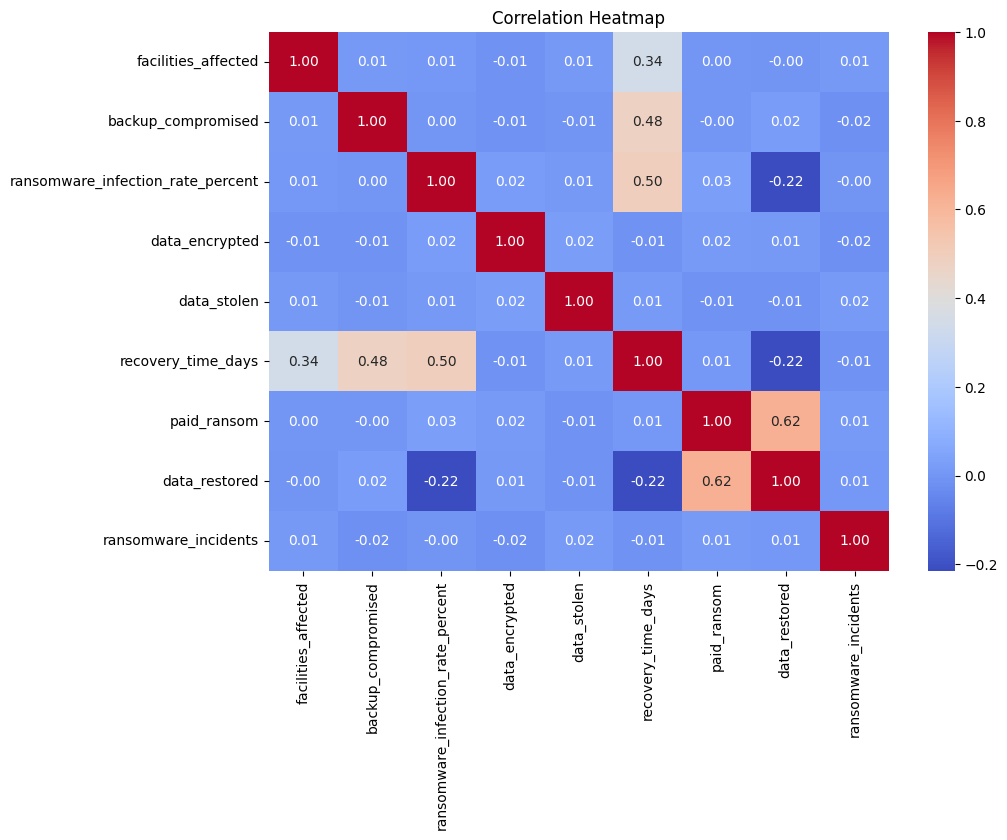

In [ ]:
# Convert boolean columns to integers for correlation
corr_df = df.copy()

bool_cols = corr_df.select_dtypes(include=["bool"]).columns
corr_df[bool_cols] = corr_df[bool_cols].astype(int)

numeric_corr_cols = corr_df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10,7))
sns.heatmap(corr_df[numeric_corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Outlier detection using boxplots**

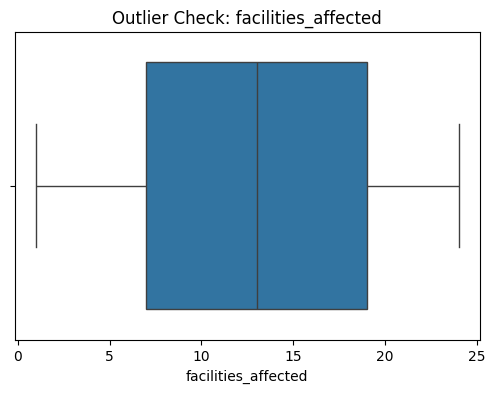

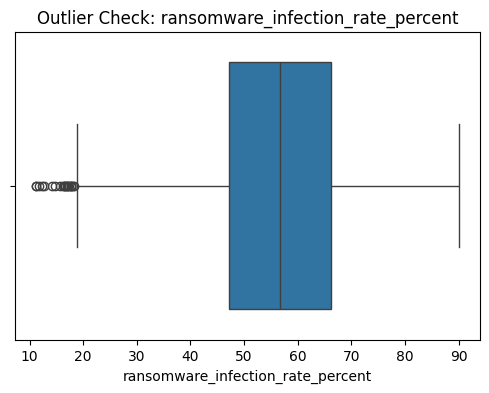

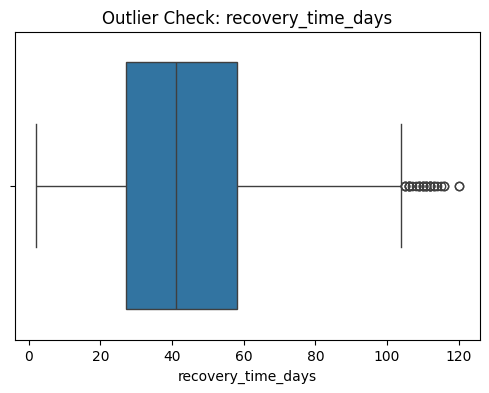

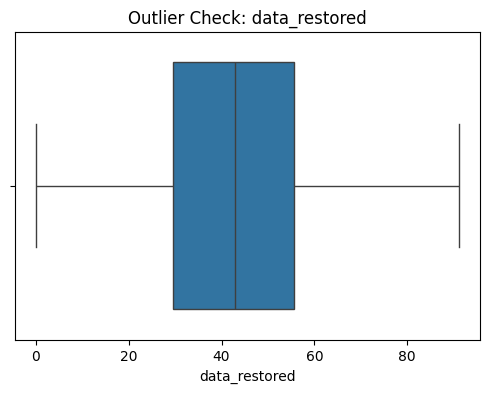

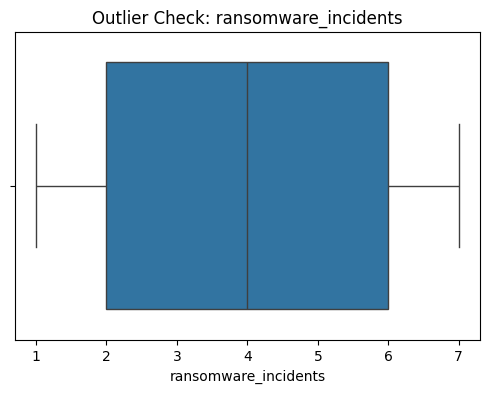

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Check: {col}")
    plt.show()

**Handle outliers using IQR clipping**

In [ ]:
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
facilities_affected,5000.0,12.763200,6.936624,1.00000,7.00,13.000,19.0000,24.00
ransomware_infection_rate_percent,5000.0,56.320991,14.687585,18.84125,47.21,56.730,66.1225,90.00
recovery_time_days,5000.0,43.722400,21.392853,2.00000,27.00,41.000,58.0000,104.50
data_restored,5000.0,42.760220,16.945095,0.00000,29.43,42.995,55.5700,91.13
ransomware_incidents,5000.0,4.022800,1.991350,1.00000,2.00,4.000,6.0000,7.00


**Feature engineering**

In [ ]:
df_fe = df_clean.copy()

# Convert booleans into numeric form for engineered features
for col in ["backup_compromised", "data_encrypted", "data_stolen", "paid_ransom"]:
    df_fe[col + "_num"] = df_fe[col].astype(int)

# Feature 1: Risk Score
df_fe["risk_score"] = (
    df_fe["ransomware_infection_rate_percent"] * 0.30 +
    df_fe["facilities_affected"] * 2 +
    df_fe["backup_compromised_num"] * 20 +
    df_fe["data_stolen_num"] * 15 +
    df_fe["ransomware_incidents"] * 5
)

# Feature 2: Recovery Efficiency Ratio
df_fe["recovery_efficiency_ratio"] = (
    df_fe["data_restored"] / (df_fe["recovery_time_days"] + 1)
)

# Feature 3: Attack Severity Index
df_fe["attack_severity_index"] = (
    df_fe["ransomware_infection_rate_percent"] +
    df_fe["recovery_time_days"] +
    df_fe["facilities_affected"] +
    df_fe["data_encrypted_num"] * 20 +
    df_fe["data_stolen_num"] * 20
)

# Extra useful date features
df_fe["attack_month"] = df_fe["attack_date"].dt.month
df_fe["attack_dayofweek"] = df_fe["attack_date"].dt.dayofweek
df_fe["attack_hour"] = df_fe["attack_date"].dt.hour

df_fe[[
    "risk_score",
    "recovery_efficiency_ratio",
    "attack_severity_index",
    "attack_month",
    "attack_dayofweek",
    "attack_hour"
]].head()

,risk_score,recovery_efficiency_ratio,attack_severity_index,attack_month,attack_dayofweek,attack_hour
0,94.990,0.558154,170.30,6,4,0
1,70.715,1.988276,131.05,12,2,3
2,108.000,1.237000,177.00,10,5,9
3,73.396,0.920000,122.32,7,6,19
4,73.095,5.400714,122.65,6,3,18


**Prepare features and target for main model**

In [ ]:
target = "paid_ransom"

drop_cols = [
    "id",
    "attack_date",
    "paid_ransom",
    "paid_ransom_num"
]

X = df_fe.drop(columns=drop_cols)
y = df_fe[target].astype(int)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print(y.value_counts())

Feature shape: (5000, 22)
Target shape: (5000,)
paid_ransom
0    2532
1    2468
Name: count, dtype: int64


**Identify numerical and categorical columns**

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numerical features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numerical features: ['facilities_affected', 'ransomware_infection_rate_percent', 'recovery_time_days', 'data_restored', 'ransomware_incidents', 'backup_compromised_num', 'data_encrypted_num', 'data_stolen_num', 'risk_score', 'recovery_efficiency_ratio', 'attack_severity_index']

Categorical features: ['org_type', 'org_size', 'cyber_threats_tracked', 'monitoring_freq', 'backup_compromised', 'data_encrypted', 'data_stolen', 'entry_method']


**Train-test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 22)
Testing set: (1000, 22)


**Preprocessing pipeline**

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Part 3: Model Development**
Evaluation function

In [ ]:
results = []

def evaluate_model(model_name, model, X_test, y_test, balancing_method="Original"):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = np.nan

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Balancing": balancing_method,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print(f"\nModel: {model_name}")
    print(f"Balancing Method: {balancing_method}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
        plt.plot([0,1], [0,1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {model_name}")
        plt.legend()
        plt.show()

**Model 1 — Logistic Regression**


Model: Logistic Regression
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       506
           1       0.85      0.89      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000

Confusion Matrix:
[[428  78]
 [ 52 442]]


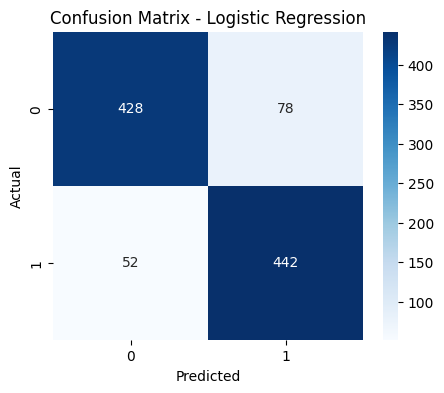

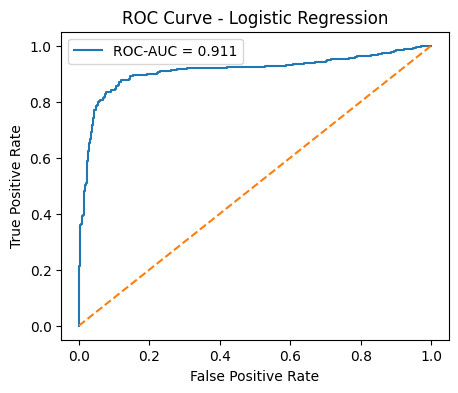

In [ ]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg.fit(X_train, y_train)
evaluate_model("Logistic Regression", log_reg, X_test, y_test)

**Model 2 — Random Forest**


Model: Random Forest
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       506
           1       0.88      0.86      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000

Confusion Matrix:
[[445  61]
 [ 67 427]]


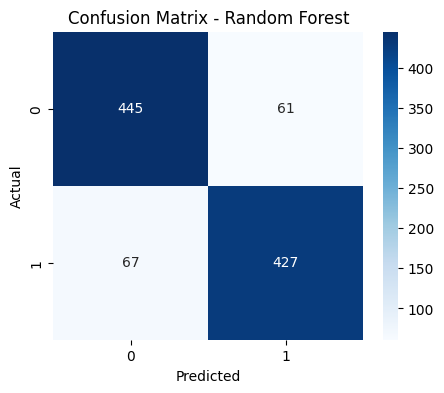

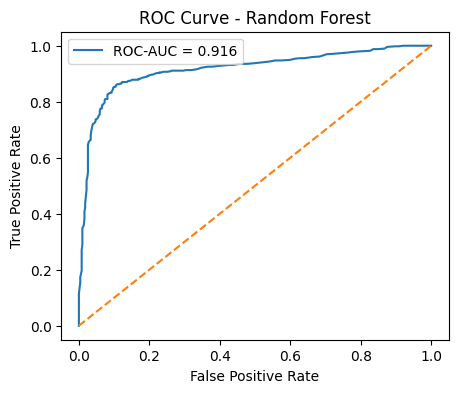

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight=None
    ))
])

rf_model.fit(X_train, y_train)
evaluate_model("Random Forest", rf_model, X_test, y_test)

**Model 3 — XGBoost**


Model: XGBoost
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       506
           1       0.90      0.85      0.87       494

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000

Confusion Matrix:
[[459  47]
 [ 75 419]]


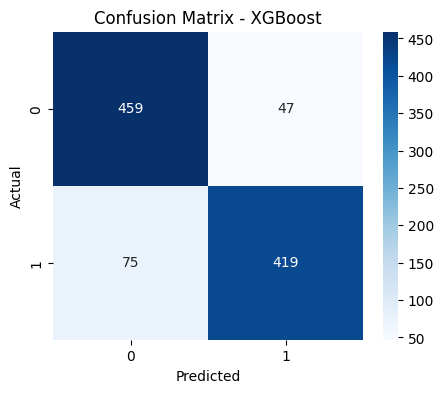

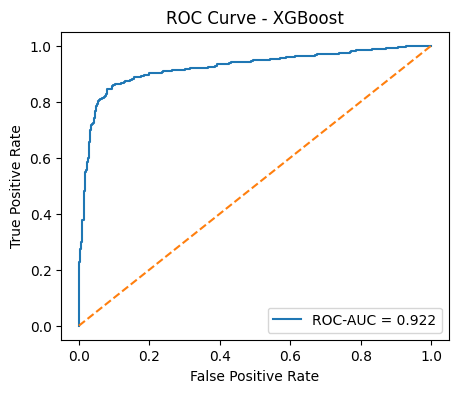

In [ ]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

**Model 4 — Neural Network**


Model: Neural Network
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       506
           1       0.80      0.83      0.82       494

    accuracy                           0.81      1000
   macro avg       0.82      0.82      0.81      1000
weighted avg       0.82      0.81      0.81      1000

Confusion Matrix:
[[406 100]
 [ 85 409]]


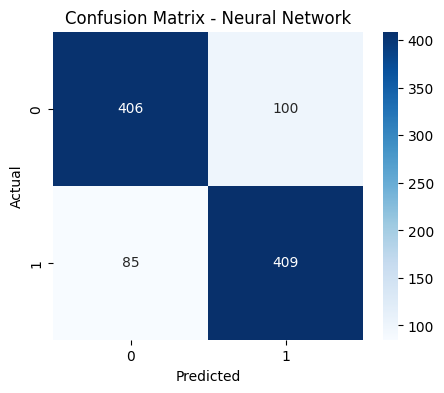

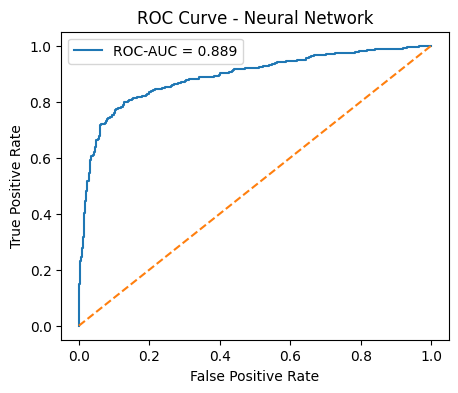

In [ ]:
nn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

nn_model.fit(X_train, y_train)
evaluate_model("Neural Network", nn_model, X_test, y_test)

**Model 5 — Isolation Forest**

Isolation Forest Results:
              precision    recall  f1-score   support

           0       0.50      0.90      0.64       506
           1       0.44      0.09      0.14       494

    accuracy                           0.49      1000
   macro avg       0.47      0.49      0.39      1000
weighted avg       0.47      0.49      0.40      1000



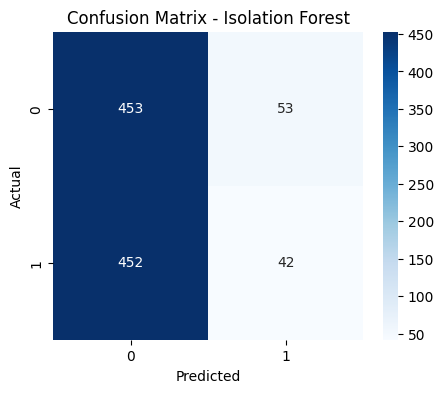

In [ ]:
# Preprocess data first
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42
)

iso_model.fit(X_train_processed)

# Isolation Forest gives -1 for anomaly and 1 for normal
iso_pred_raw = iso_model.predict(X_test_processed)

# Convert anomaly result into binary class
# anomaly = 1, normal = 0
iso_pred = np.where(iso_pred_raw == -1, 1, 0)

print("Isolation Forest Results:")
print(classification_report(y_test, iso_pred))

cm = confusion_matrix(y_test, iso_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

results.append({
    "Model": "Isolation Forest",
    "Balancing": "Original",
    "Accuracy": accuracy_score(y_test, iso_pred),
    "Precision": precision_score(y_test, iso_pred),
    "Recall": recall_score(y_test, iso_pred),
    "F1-score": f1_score(y_test, iso_pred),
    "ROC-AUC": np.nan
})

**Analyze class imbalance**

In [ ]:
class_counts = y.value_counts()
class_percentage = y.value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    "Class Count": class_counts,
    "Percentage": class_percentage
})

imbalance_df

,Class Count,Percentage
paid_ransom,,
0,2532,50.64
1,2468,49.36


**define all models and balancing techniques**

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Supervised models only
# Isolation Forest is unsupervised, so it is not suitable for SMOTE/class weighting comparison.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        eval_metric="logloss",
        random_state=42
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    )
}

balancing_methods = {
    "Original": None,
    "SMOTE": SMOTE(random_state=42),
    "Undersampling": RandomUnderSampler(random_state=42)
}

**Train all models with Original, SMOTE, and Undersampling**

Training Model: Logistic Regression
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       506
           1       0.85      0.89      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



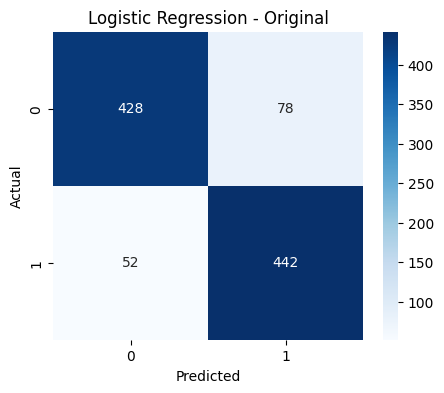

Training Model: Logistic Regression
Balancing Method: SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       506
           1       0.85      0.89      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



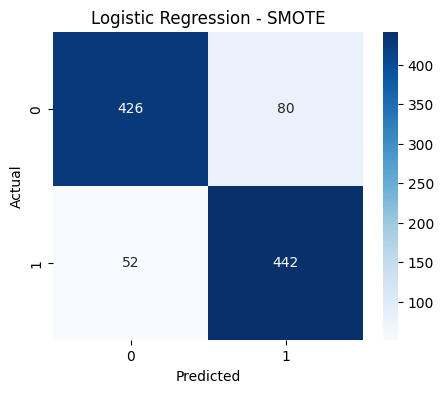

Training Model: Logistic Regression
Balancing Method: Undersampling

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       506
           1       0.85      0.89      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



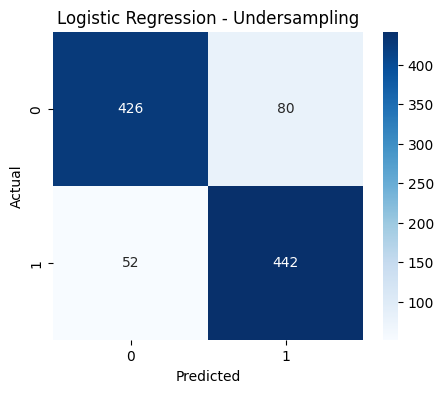

Training Model: Random Forest
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       506
           1       0.88      0.86      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



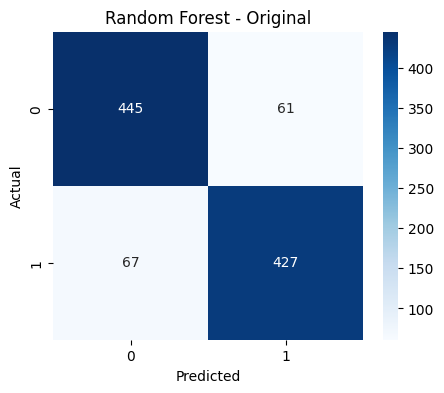

Training Model: Random Forest
Balancing Method: SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       506
           1       0.88      0.86      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



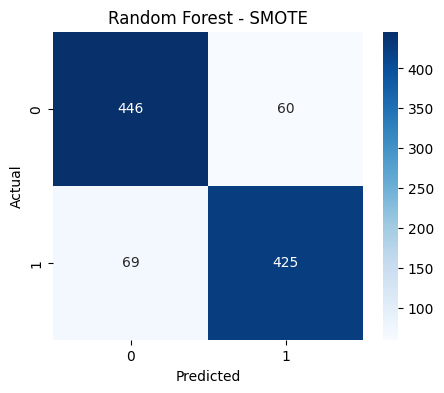

Training Model: Random Forest
Balancing Method: Undersampling

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       506
           1       0.87      0.87      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



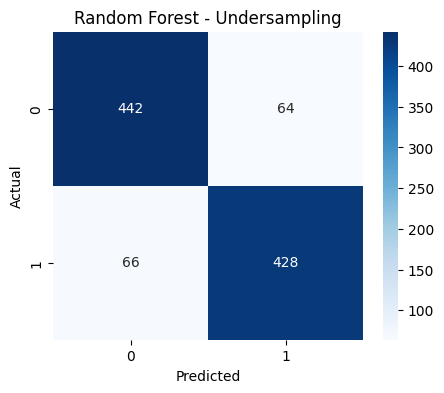

Training Model: XGBoost
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       506
           1       0.90      0.85      0.87       494

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



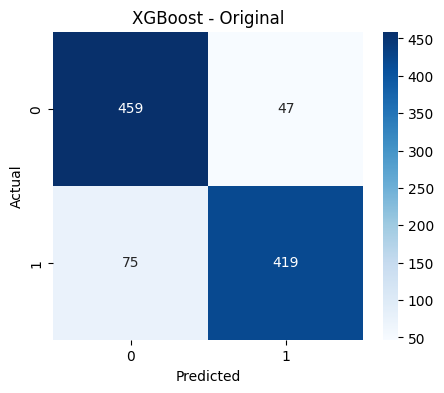

Training Model: XGBoost
Balancing Method: SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       506
           1       0.90      0.85      0.87       494

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



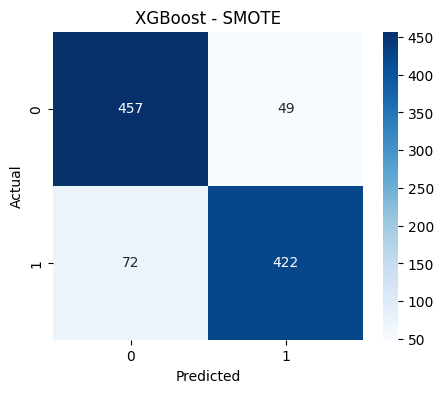

Training Model: XGBoost
Balancing Method: Undersampling

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       506
           1       0.90      0.85      0.87       494

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



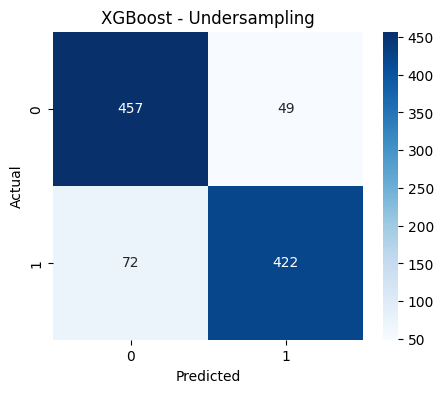

Training Model: Neural Network
Balancing Method: Original

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       506
           1       0.80      0.83      0.82       494

    accuracy                           0.81      1000
   macro avg       0.82      0.82      0.81      1000
weighted avg       0.82      0.81      0.81      1000



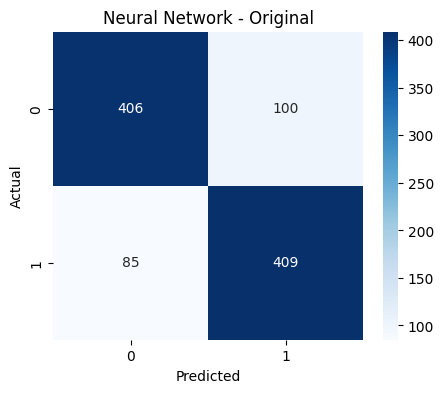

Training Model: Neural Network
Balancing Method: SMOTE

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       506
           1       0.80      0.86      0.83       494

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



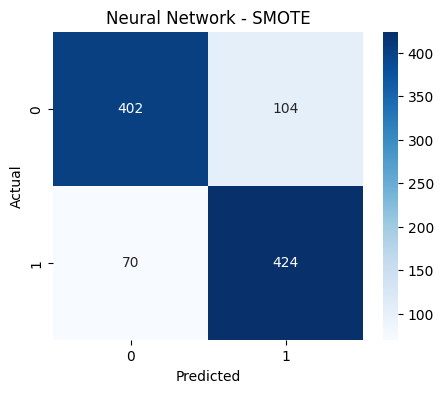

Training Model: Neural Network
Balancing Method: Undersampling

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       506
           1       0.80      0.87      0.83       494

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



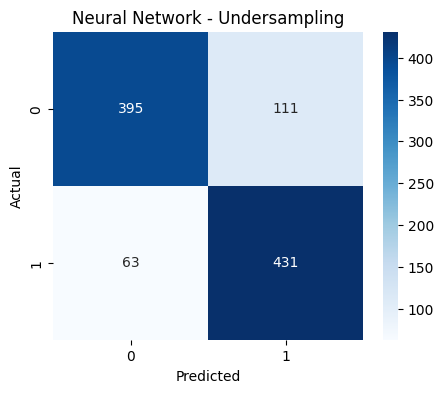

In [ ]:
all_results = []

for model_name, model in models.items():
    for balance_name, sampler in balancing_methods.items():

        print("=" * 80)
        print(f"Training Model: {model_name}")
        print(f"Balancing Method: {balance_name}")
        print("=" * 80)

        if sampler is None:
            pipeline = Pipeline(steps=[
                ("preprocessor", preprocessor),
                ("classifier", model)
            ])
        else:
            pipeline = ImbPipeline(steps=[
                ("preprocessor", preprocessor),
                ("sampler", sampler),
                ("classifier", model)
            ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        if hasattr(pipeline.named_steps["classifier"], "predict_proba"):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            roc_auc = np.nan

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        all_results.append({
            "Model": model_name,
            "Balancing Method": balance_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "ROC-AUC": roc_auc
        })

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))

        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{model_name} - {balance_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

**Class weighting for supported models**

Training Model: Logistic Regression
Balancing Method: Class Weighting

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86       506
           1       0.85      0.89      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



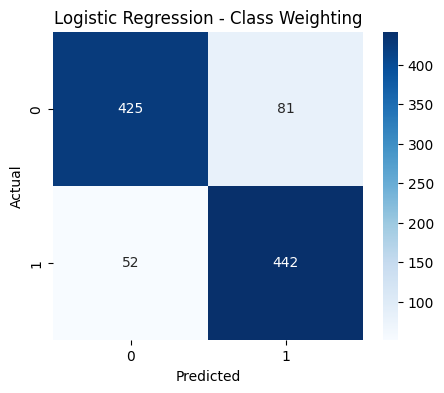

Training Model: Random Forest
Balancing Method: Class Weighting

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       506
           1       0.88      0.86      0.87       494

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



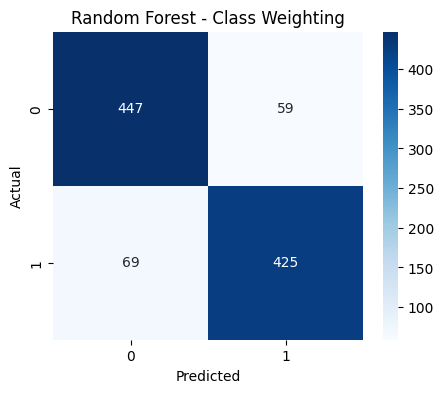

Training Model: XGBoost
Balancing Method: Class Weighting

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       506
           1       0.89      0.86      0.87       494

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



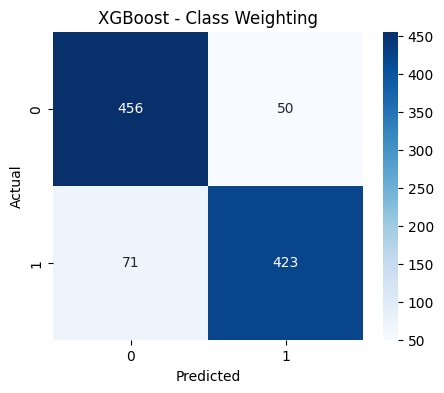

In [ ]:
class_weight_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    )
}

for model_name, model in class_weight_models.items():

    print("=" * 80)
    print(f"Training Model: {model_name}")
    print("Balancing Method: Class Weighting")
    print("=" * 80)

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    all_results.append({
        "Model": model_name,
        "Balancing Method": "Class Weighting",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Class Weighting")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**Compare before and after balancing**

In [ ]:
comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df.sort_values(
    by=["Model", "F1-score"],
    ascending=[True, False]
)

comparison_df

,Model,Balancing Method,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Original,0.870,0.850000,0.894737,0.871795,0.910647
1,Logistic Regression,SMOTE,0.868,0.846743,0.894737,0.870079,0.910743
2,Logistic Regression,Undersampling,0.868,0.846743,0.894737,0.870079,0.910671
12,Logistic Regression,Class Weighting,0.867,0.845124,0.894737,0.869223,0.910607
11,Neural Network,Undersampling,0.826,0.795203,0.872470,0.832046,0.900810
10,Neural Network,SMOTE,0.826,0.803030,0.858300,0.829746,0.896049
9,Neural Network,Original,0.815,0.803536,0.827935,0.815553,0.889148
3,Random Forest,Original,0.872,0.875000,0.864372,0.869654,0.915740
13,Random Forest,Class Weighting,0.872,0.878099,0.860324,0.869121,0.916232
4,Random Forest,SMOTE,0.871,0.876289,0.860324,0.868233,0.909695


**Find best result for each model**

In [ ]:
best_per_model = comparison_df.loc[
    comparison_df.groupby("Model")["F1-score"].idxmax()
]

best_per_model

,Model,Balancing Method,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Original,0.870,0.850000,0.894737,0.871795,0.910647
11,Neural Network,Undersampling,0.826,0.795203,0.872470,0.832046,0.900810
3,Random Forest,Original,0.872,0.875000,0.864372,0.869654,0.915740
14,XGBoost,Class Weighting,0.879,0.894292,0.856275,0.874871,0.920961


**Overall best model**

In [ ]:
overall_best = comparison_df.sort_values(by="F1-score", ascending=False).iloc[0]

print("Overall Best Model:")
print(overall_best)

Overall Best Model:
Model                       XGBoost
Balancing Method    Class Weighting
Accuracy                      0.879
Precision                  0.894292
Recall                     0.856275
F1-score                   0.874871
ROC-AUC                    0.920961
Name: 14, dtype: object


**Visual comparison**

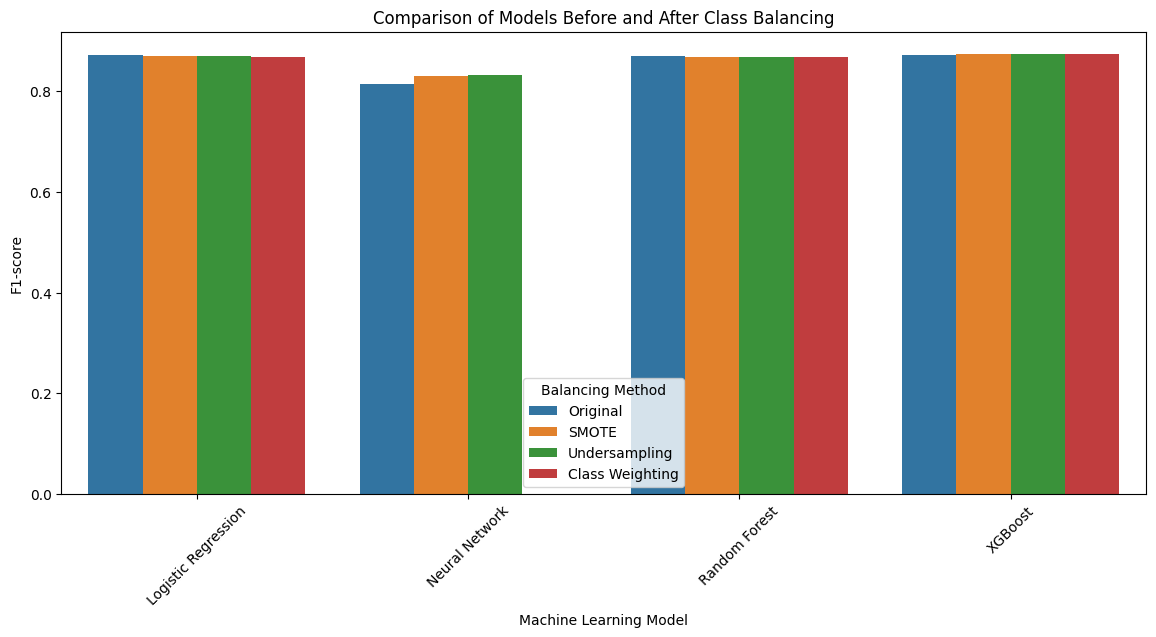

In [ ]:
plt.figure(figsize=(14, 6))
sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1-score",
    hue="Balancing Method"
)

plt.title("Comparison of Models Before and After Class Balancing")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.legend(title="Balancing Method")
plt.show()

**Evaluation Summary**
Select best model

In [ ]:
# Find overall best model after original + balancing comparison

comparison_df = pd.DataFrame(all_results)

comparison_df = comparison_df.sort_values(
    by="F1-score",
    ascending=False
)

best_model_row = comparison_df.iloc[0]

print("Overall Best Model Based on F1-score:")
print(best_model_row)

comparison_df

Overall Best Model Based on F1-score:
Model                       XGBoost
Balancing Method    Class Weighting
Accuracy                      0.879
Precision                  0.894292
Recall                     0.856275
F1-score                   0.874871
ROC-AUC                    0.920961
Name: 14, dtype: object


,Model,Balancing Method,Accuracy,Precision,Recall,F1-score,ROC-AUC
14,XGBoost,Class Weighting,0.879,0.894292,0.856275,0.874871,0.920961
7,XGBoost,SMOTE,0.879,0.895966,0.854251,0.874611,0.925485
8,XGBoost,Undersampling,0.879,0.895966,0.854251,0.874611,0.922661
6,XGBoost,Original,0.878,0.899142,0.848178,0.872917,0.921873
0,Logistic Regression,Original,0.870,0.850000,0.894737,0.871795,0.910647
2,Logistic Regression,Undersampling,0.868,0.846743,0.894737,0.870079,0.910671
1,Logistic Regression,SMOTE,0.868,0.846743,0.894737,0.870079,0.910743
3,Random Forest,Original,0.872,0.875000,0.864372,0.869654,0.915740
12,Logistic Regression,Class Weighting,0.867,0.845124,0.894737,0.869223,0.910607
13,Random Forest,Class Weighting,0.872,0.878099,0.860324,0.869121,0.916232


**Explainable AI**
Random Forest feature importance

In [ ]:
# Use trained Random Forest model
trained_rf = rf_model.named_steps["classifier"]

# Get feature names after one-hot encoding
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = trained_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
3,num__data_restored,0.415346
9,num__recovery_efficiency_ratio,0.128421
10,num__attack_severity_index,0.062182
1,num__ransomware_infection_rate_percent,0.061314
2,num__recovery_time_days,0.058151
8,num__risk_score,0.050883
0,num__facilities_affected,0.038742
4,num__ransomware_incidents,0.025126
19,cat__cyber_threats_tracked_1-50,0.009661
20,cat__cyber_threats_tracked_350+,0.008716


**Plot top 15 important features**

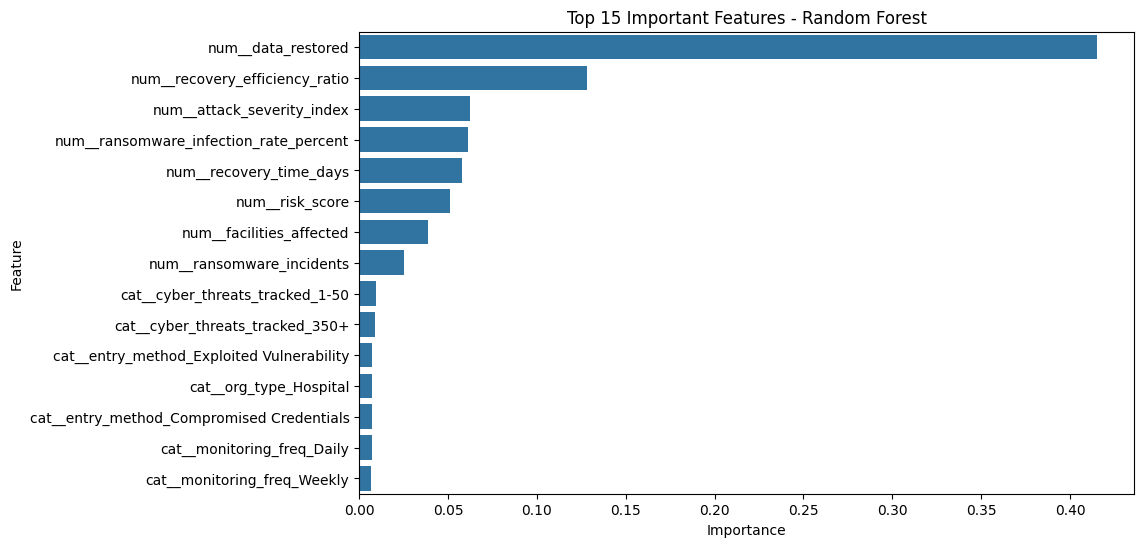

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Important Features - Random Forest")
plt.show()

**SHAP explainability for XGBoost**

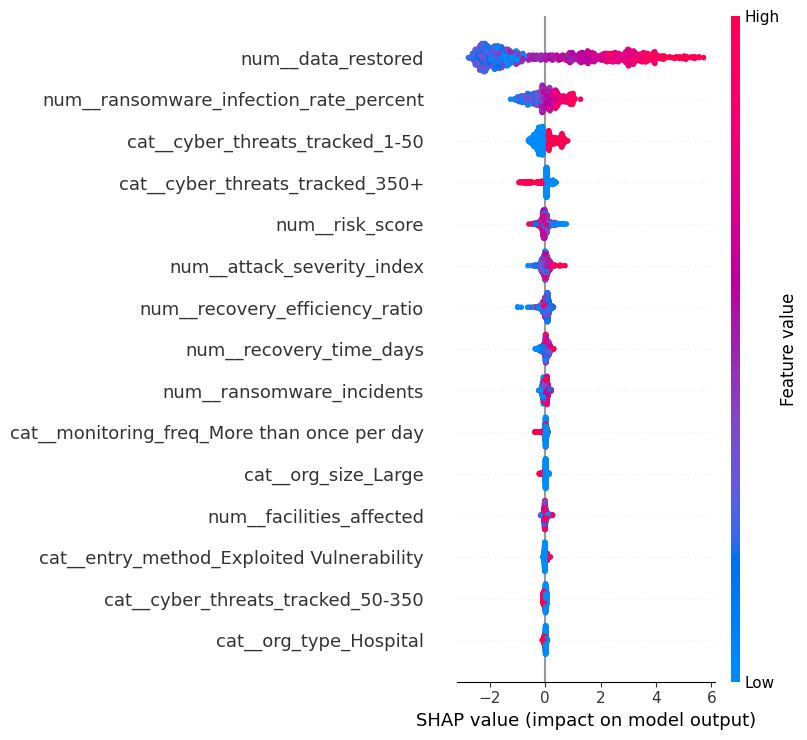

In [ ]:
# Transform training and testing data
X_train_transformed = xgb_model.named_steps["preprocessor"].transform(X_train)
X_test_transformed = xgb_model.named_steps["preprocessor"].transform(X_test)

feature_names_xgb = xgb_model.named_steps["preprocessor"].get_feature_names_out()

# Convert sparse matrix to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()

xgb_classifier = xgb_model.named_steps["classifier"]

explainer = shap.TreeExplainer(xgb_classifier)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names_xgb,
    max_display=15
)

**LIME explanation for one prediction**

In [ ]:
# Prepare transformed data for LIME
X_train_lime = log_reg.named_steps["preprocessor"].transform(X_train)
X_test_lime = log_reg.named_steps["preprocessor"].transform(X_test)

if hasattr(X_train_lime, "toarray"):
    X_train_lime = X_train_lime.toarray()
    X_test_lime = X_test_lime.toarray()

feature_names_lime = log_reg.named_steps["preprocessor"].get_feature_names_out()

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names_lime,
    class_names=["No Ransom Payment", "Ransom Paid"],
    mode="classification"
)

i = 0

lime_exp = lime_explainer.explain_instance(
    X_test_lime[i],
    log_reg.named_steps["classifier"].predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

**Second ML Problem: Attack Success Prediction**

**Build second target model for data_encrypted**

In [ ]:
target2 = "data_encrypted"

drop_cols2 = [
    "id",
    "attack_date",
    "data_encrypted",
    "data_encrypted_num"
]

X2 = df_fe.drop(columns=drop_cols2)
y2 = df_fe[target2].astype(int)

print("Second problem target distribution:")
print(y2.value_counts())
print(y2.value_counts(normalize=True) * 100)

Second problem target distribution:
data_encrypted
1    4241
0     759
Name: count, dtype: int64
data_encrypted
1    84.82
0    15.18
Name: proportion, dtype: float64


**Train-test split for second ML problem**

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42,
    stratify=y2
)

numeric_features2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features2 = X2.select_dtypes(include=["object", "bool"]).columns.tolist()

numeric_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor2 = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer2, numeric_features2),
        ("cat", categorical_transformer2, categorical_features2)
    ]
)

**Random Forest with SMOTE for attack success prediction**

Attack Success Prediction Results:
              precision    recall  f1-score   support

           0       0.70      0.11      0.18       152
           1       0.86      0.99      0.92       848

    accuracy                           0.86      1000
   macro avg       0.78      0.55      0.55      1000
weighted avg       0.84      0.86      0.81      1000

ROC-AUC: 0.8445684893247268


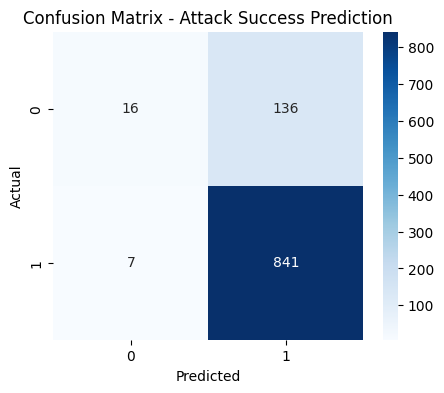

In [ ]:
rf_attack_success = ImbPipeline(steps=[
    ("preprocessor", preprocessor2),
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_attack_success.fit(X2_train, y2_train)

y2_pred = rf_attack_success.predict(X2_test)
y2_prob = rf_attack_success.predict_proba(X2_test)[:, 1]

print("Attack Success Prediction Results:")
print(classification_report(y2_test, y2_pred))
print("ROC-AUC:", roc_auc_score(y2_test, y2_prob))

cm = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Attack Success Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()